#Setup: Getting PySpark

In [ ]:
# ============================================
# CELL 1: Install PySpark in Colab
# ============================================

!pip install pyspark==3.5.0 -q

print("✅ PySpark installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 15.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.0.2 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.0 which is incompatible.
✅ PySpark installed!


**WHAT IS A SPARK SESSION?**
    
    Think of it as "opening" PySpark, like opening Excel.
    You do this once, then use it throughout your notebook.

In [ ]:
# ============================================
# CELL 2: Initialize Spark Session
# ============================================

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("DemandForecasting_FeatureEngineering") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

print(f"✅ Spark version: {spark.version}")
print(f"✅ Spark session created successfully!")

✅ Spark version: 3.5.0
✅ Spark session created successfully!


In [ ]:
# ============================================
# CELL 3: Authenticate with Google Cloud
# ============================================

from google.colab import auth
auth.authenticate_user()

print("✅ Authenticated with Google Cloud!")

✅ Authenticated with Google Cloud!


**WHAT'S HAPPENING:**

    We're pulling data FROM BigQuery (cloud database)
    INTO PySpark DataFrames (in Colab's memory)

Think of it as: downloading from cloud database → loading into PySpark

In [ ]:
# ============================================
# CELL 4: Load ALL tables from BigQuery into PySpark DataFrames
# ============================================

from google.cloud import bigquery
import pandas as pd

PROJECT_ID = 'project-9088eb2a-a4cc-4580-8e6'
client = bigquery.Client(project=PROJECT_ID)

def load_from_bigquery(table_name):
    """Load a BigQuery table into a PySpark DataFrame"""
    query = f"SELECT * FROM `{PROJECT_ID}.demand_forecasting.{table_name}`"
    pandas_df = client.query(query).to_dataframe()
    spark_df = spark.createDataFrame(pandas_df)
    print(f"  ✅ {table_name}: {spark_df.count():,} rows, {len(spark_df.columns)} columns")
    return spark_df

print("Loading data from BigQuery...")

df_sales = load_from_bigquery('sales')
df_stores = load_from_bigquery('stores')
df_oil = load_from_bigquery('Oil')
df_holidays = load_from_bigquery('holidays')
df_transactions = load_from_bigquery('transactions')

print("\n✅ All tables loaded into PySpark!")

Loading data from BigQuery...
  ✅ sales: 3,000,888 rows, 6 columns
  ✅ stores: 54 rows, 5 columns
  ✅ Oil: 1,218 rows, 2 columns
  ✅ holidays: 350 rows, 6 columns
  ✅ transactions: 83,488 rows, 3 columns

✅ All tables loaded into PySpark!


In [ ]:
# ============================================
# CELL 5: Verify the data looks right
# ============================================

print("=" * 60)
print("SALES TABLE (main data)")
print("=" * 60)
df_sales.printSchema()
df_sales.show(5)

print("\n" + "=" * 60)
print("STORES TABLE")
print("=" * 60)
df_stores.show(5)

print("\n" + "=" * 60)
print("OIL TABLE")
print("=" * 60)
df_oil.show(5)

SALES TABLE (main data)
root
 |-- id: long (nullable = true)
 |-- date: string (nullable = true)
 |-- store_nbr: long (nullable = true)
 |-- family: string (nullable = true)
 |-- sales: double (nullable = true)
 |-- onpromotion: long (nullable = true)

+-----+----------+---------+----------+-----+-----------+
|   id|      date|store_nbr|    family|sales|onpromotion|
+-----+----------+---------+----------+-----+-----------+
|    0|2013-01-01|        1|AUTOMOTIVE|  0.0|          0|
| 3564|2013-01-03|        1|AUTOMOTIVE|  3.0|          0|
|21384|2013-01-13|        1|AUTOMOTIVE|  2.0|          0|
|24948|2013-01-15|        1|AUTOMOTIVE|  1.0|          0|
|26730|2013-01-16|        1|AUTOMOTIVE|  1.0|          0|
+-----+----------+---------+----------+-----+-----------+
only showing top 5 rows


STORES TABLE
+---------+-----+---------+----+-------+
|store_nbr| city|    state|type|cluster|
+---------+-----+---------+----+-------+
|       44|Quito|Pichincha|   A|      5|
|       45|Quito|Pichi

# Phase 1: Data Preparation (Clean Before Engineering)

### Fix data types and clean data

WHAT THIS DOES:
    
    Before: date = "2017-03-15" (text string)
    After:  date = 2017-03-15 (actual date, understands calendar)

WHY IT MATTERS:
    
    With a string, you can't do: date + 7 days, or extract month
    With a date, PySpark understands it's March 15th, a Wednesday

In [ ]:
# ============================================
# CELL 6: Fix data types and clean data
# ============================================

from pyspark.sql import functions as F
from pyspark.sql.window import Window

# ────────────────────────────────────────────
# STEP 1: Fix date columns
# ────────────────────────────────────────────

# The date column might be a string like "2017-03-15"
# We need it as a proper DATE type so we can extract day, month, etc.

df_sales = df_sales.withColumn(
    'date', F.to_date(F.col('date'), 'yyyy-MM-dd')
)

df_oil = df_oil.withColumn(
    'date', F.to_date(F.col('date'), 'yyyy-MM-dd')
)

# And holidays
df_holidays = df_holidays.withColumn(
    'date', F.to_date(F.col('date'), 'yyyy-MM-dd')
)

# And transactions
df_transactions = df_transactions.withColumn(
    'date', F.to_date(F.col('date'), 'yyyy-MM-dd')
)

print("✅ Date columns fixed")
df_sales.select('date').show(3)

✅ Date columns fixed
+----------+
|      date|
+----------+
|2013-01-01|
|2013-01-03|
|2013-01-13|
+----------+
only showing top 3 rows



### Handle oil price missing values

BUSINESS CONTEXT:
    
    Oil prices aren't reported on weekends/holidays.
    But stores are still open. We need oil prices for every day.
    Solution: Forward-fill (use last known price)

WHAT IS FORWARD-FILL?
   
    Monday: $48.50
    Tuesday: $47.20
    Wednesday: NULL (no trading)  → becomes $47.20 (Tuesday's price)
    Thursday: $49.00
We assume: if no new price today, yesterday's price still applies.

In [ ]:
# ============================================
# CELL 7: Handle oil price missing values
# ============================================

# First, rename the oil price column to something readable
df_oil = df_oil.withColumnRenamed('dcoilwtico', 'oil_price')

# Forward-fill: Use last known oil price for missing days
oil_window = Window.orderBy('date') \
                   .rowsBetween(Window.unboundedPreceding, 0)

df_oil = df_oil.withColumn(
    'oil_price',
    F.last('oil_price', ignorenulls=True).over(oil_window)
)

# Check: how many nulls remain?
null_count = df_oil.filter(F.col('oil_price').isNull()).count()
print(f"Remaining null oil prices: {null_count}")
print("✅ Oil prices forward-filled")
df_oil.show(5)

Remaining null oil prices: 0
✅ Oil prices forward-filled
+----------+---------+
|      date|oil_price|
+----------+---------+
|2013-01-01|      NaN|
|2013-01-02|    93.14|
|2013-01-03|    92.97|
|2013-01-04|    93.12|
|2013-01-07|     93.2|
+----------+---------+
only showing top 5 rows



### Prepare holidays table

BUSINESS CONTEXT:

The holidays table has different types:
  
    Holiday → stores might close → demand DROPS
    Transfer → holiday moved → original day is NORMAL
    Bridge → extra day off → demand changes
    Event → could INCREASE demand (sports event, festival)
    Work Day → normally a day off, but stores open → NORMAL demand

In [ ]:
# ============================================
# CELL 8: Prepare holidays table
# ============================================

# Create a clean holiday flag table
# Keep only holidays that affect demand (National level)
df_holidays_clean = df_holidays.filter(
    (F.col('locale') == 'National') &
    (F.col('type').isin(['Holiday', 'Event', 'Bridge']))
)

# Create a simple date → holiday_type mapping
df_holiday_flags = df_holidays_clean.select(
    'date',
    F.col('type').alias('holiday_type'),
    F.col('description').alias('holiday_name')
).dropDuplicates(['date'])

# If multiple holidays on same date, keep one
print(f"Holiday dates in dataset: {df_holiday_flags.count()}")
df_holiday_flags.show(5)
print("✅ Holidays table cleaned")

Holiday dates in dataset: 119
+----------+------------+--------------------+
|      date|holiday_type|        holiday_name|
+----------+------------+--------------------+
|2012-08-10|     Holiday|Primer Grito de I...|
|2012-10-09|     Holiday|Independencia de ...|
|2012-11-02|     Holiday|     Dia de Difuntos|
|2012-11-03|     Holiday|Independencia de ...|
|2012-12-24|      Bridge|      Puente Navidad|
+----------+------------+--------------------+
only showing top 5 rows

✅ Holidays table cleaned


###JOIN ALL TABLES TOGETHER

We're combining:
    
    Sales data (what we're predicting)
    Store metadata (WHERE it's sold)
    Oil prices (economic context)
    Holidays (calendar context)
    Transactions (foot traffic)

In [ ]:
# ============================================
# CELL 9: JOIN ALL TABLES TOGETHER
# ============================================

# Join 1: Sales + Store info
df = df_sales.join(
    df_stores,
    on='store_nbr',
    how='left'    # LEFT join: keep all sales rows, add store info where available
)

# Join 2: + Oil prices
df = df.join(
    df_oil,
    on='date',
    how='left'    # Some dates might not have oil prices
)

# Join 3: + Holiday flags
df = df.join(
    df_holiday_flags,
    on='date',
    how='left'    # Most days are NOT holidays → null is fine (we'll handle it)
)

# Join 4: + Transaction counts
df = df.join(
    df_transactions,
    on=['date', 'store_nbr'],
    how='left'
)

# Fill nulls from joins
df = df.withColumn(
    'is_holiday',
    F.when(F.col('holiday_type').isNotNull(), 1).otherwise(0)
)

df = df.withColumn(
    'oil_price',
    F.when(F.col('oil_price').isNull(), F.lit(50.0))  # median fill for remaining nulls
     .otherwise(F.col('oil_price'))
)

print(f"Combined dataset: {df.count():,} rows, {len(df.columns)} columns")
print(f"\nColumns: {df.columns}")
df.show(3)
print("✅ All tables joined!")

Combined dataset: 3,000,888 rows, 15 columns

Columns: ['date', 'store_nbr', 'id', 'family', 'sales', 'onpromotion', 'city', 'state', 'type', 'cluster', 'oil_price', 'holiday_type', 'holiday_name', 'transactions', 'is_holiday']
+----------+---------+-----+----------+-----+-----------+-----+---------+----+-------+---------+------------+------------+------------+----------+
|      date|store_nbr|   id|    family|sales|onpromotion| city|    state|type|cluster|oil_price|holiday_type|holiday_name|transactions|is_holiday|
+----------+---------+-----+----------+-----+-----------+-----+---------+----+-------+---------+------------+------------+------------+----------+
|2013-02-02|        1|57024|AUTOMOTIVE|  0.0|          0|Quito|Pichincha|   D|     13|     50.0|        NULL|        NULL|        1377|         0|
|2013-01-26|        1|44550|AUTOMOTIVE|  4.0|          0|Quito|Pichincha|   D|     13|     50.0|        NULL|        NULL|        1295|         0|
|2013-01-10|        1|16038|AUTOMOTIV

### Filter to our modeling subset

FROM EDA, we discovered:
    
    → Top 10 categories cover 85% of sales
    → Top 10 stores cover 55% of revenue
    → Sparse categories (>70% zeros) are unpredictable

We're applying those business-driven EDA decisions now.
This is WHY EDA matters — it directly shapes engineering.

In [ ]:
# ============================================
# CELL 10: Filter to our modeling subset
# ============================================

# Top 10 product categories by total sales
top_categories = (
    df.groupBy('family')
    .agg(F.sum('sales').alias('total_sales'))
    .orderBy(F.desc('total_sales'))
    .limit(10)
    .select('family')
    .rdd.flatMap(lambda x: x)
    .collect()
)

print("Top 10 categories:", top_categories)

# Top 10 stores by total sales
top_stores = (
    df.groupBy('store_nbr')
    .agg(F.sum('sales').alias('total_sales'))
    .orderBy(F.desc('total_sales'))
    .limit(10)
    .select('store_nbr')
    .rdd.flatMap(lambda x: x)
    .collect()
)

print("Top 10 stores:", top_stores)

# Filter
df_filtered = df.filter(
    (F.col('family').isin(top_categories)) &
    (F.col('store_nbr').isin(top_stores))
)

total_before = df.count()
total_after = df_filtered.count()
print(f"\nRows before filtering: {total_before:,}")
print(f"Rows after filtering:  {total_after:,}")
print(f"Reduction: {(1 - total_after/total_before)*100:.1f}%")
print(f"But covers ~55% of total sales (from EDA finding)")

df = df_filtered
print("\n✅ Filtered to modeling subset")

Top 10 categories: ['GROCERY I', 'BEVERAGES', 'PRODUCE', 'CLEANING', 'DAIRY', 'BREAD/BAKERY', 'POULTRY', 'MEATS', 'PERSONAL CARE', 'DELI']
Top 10 stores: [44, 45, 47, 3, 49, 46, 48, 51, 8, 50]

Rows before filtering: 3,000,888
Rows after filtering:  168,400
Reduction: 94.4%
But covers ~55% of total sales (from EDA finding)

✅ Filtered to modeling subset


#Phase 2: Feature Engineering

FEATURE TIERS:

TIER 1: Basic     ← 10 features
    
    → Day of week, month, year, quarter                            

TIER 2: Standard       ← 15 features
    
    → Lag features, rolling means                                   
    
TIER 3: Advanced     ← 15 features
    
    → Rolling std, growth rates, interaction features

TIER 4: Expert       ← 15+ features
   
    → Cyclical encoding, expanding windows, cross-store features,demand volatility regime, category embeddings

We're building ALL FOUR TIERS.                                         

### TIER 1: Calendar Features

In [ ]:
# ============================================
# CELL 11: TIER 1 — Calendar/Time Features
# ============================================

print("Creating TIER 1 features: Calendar/Time...")

df = df.withColumn('day_of_week', F.dayofweek('date'))  # 1=Sun, 7=Sat
df = df.withColumn('day_of_month', F.dayofmonth('date'))
df = df.withColumn('month', F.month('date'))
df = df.withColumn('year', F.year('date'))
df = df.withColumn('week_of_year', F.weekofyear('date'))
df = df.withColumn('quarter', F.quarter('date'))

# Binary flags (easier for models to use than raw numbers)
df = df.withColumn(
    'is_weekend',
    F.when(F.dayofweek('date').isin(1, 7), 1).otherwise(0)
)

# WHY BINARY FLAGS?
# day_of_week = 7 (Saturday) doesn't tell the model "this is special"
# is_weekend = 1 directly says "demand pattern changes here"

df = df.withColumn(
    'is_month_start',
    F.when(F.dayofmonth('date') <= 5, 1).otherwise(0)
)
# BUSINESS LOGIC: People get paid at month start → spend more on groceries

df = df.withColumn(
    'is_month_end',
    F.when(F.dayofmonth('date') >= 26, 1).otherwise(0)
)
# BUSINESS LOGIC: People run low on budget at month end → spend less

df = df.withColumn(
    'is_december',
    F.when(F.month('date') == 12, 1).otherwise(0)
)

# Day of year (captures annual seasonality as a number)
df = df.withColumn(
    'day_of_year', F.dayofyear('date')
)

# Trend feature: days since the start of the dataset
min_date = df.select(F.min('date')).collect()[0][0]
df = df.withColumn(
    'days_since_start',
    F.datediff(F.col('date'), F.lit(min_date))
)

print(f"✅ TIER 1 complete: 12 calendar features added")
print(f"Total columns now: {len(df.columns)}")
df.show(5)

Creating TIER 1 features: Calendar/Time...
✅ TIER 1 complete: 12 calendar features added
Total columns now: 27


In [ ]:
# ============================================
# CELL 12: TOP FEATURE — Cyclical Encoding
# ============================================

import math

# Day of week: cycle of 7
df = df.withColumn(
    'dow_sin', F.sin(2 * math.pi * F.col('day_of_week') / 7)
)
df = df.withColumn(
    'dow_cos', F.cos(2 * math.pi * F.col('day_of_week') / 7)
)

# Month: cycle of 12
df = df.withColumn(
    'month_sin', F.sin(2 * math.pi * F.col('month') / 12)
)
df = df.withColumn(
    'month_cos', F.cos(2 * math.pi * F.col('month') / 12)
)

# Day of year: cycle of 365
df = df.withColumn(
    'doy_sin', F.sin(2 * math.pi * F.col('day_of_year') / 365)
)
df = df.withColumn(
    'doy_cos', F.cos(2 * math.pi * F.col('day_of_year') / 365)
)

print("✅ Cyclical encoding added (6 features)")

# ============================================
# VISUAL EXPLANATION:
#
#          January
#            |
#    Dec ----+---- Feb
#    /       |       \
#  Nov       |       Mar
#   |     (circle)    |
#  Oct       |       Apr
#    \       |       /
#    Sep ----+---- May
#            |
#          August
#
# On a circle, December and January are ADJACENT
# sin(Dec) ≈ sin(Jan), cos(Dec) ≈ cos(Jan)
# The model naturally learns this adjacency
# ============================================
df.show(5)

✅ Cyclical encoding added (6 features)


### TIER 2: Lag Features

In [ ]:
# ============================================
# CELL 13: TIER 2 — Lag Features
#
# BUSINESS LOGIC:
# "What happened recently is the BEST predictor of
#  what happens next."
#
# If a store sold 4000 units of GROCERY yesterday,
# it will probably sell close to 4000 today.
#
# If last Saturday it sold 5000, this Saturday will
# probably be close to 5000.
#
# LAG FEATURES capture this "recent history" signal.
#
# YOUR EDA CONFIRMED: day-of-week and recent trends
# are the strongest patterns in the data.
#
# ──────────────────────────────────────────────
#
# CRITICAL: Data Leakage Prevention
#
# WHAT IS DATA LEAKAGE?
# If you accidentally give the model information about
# the FUTURE while training, it "cheats" and looks
# amazing in training but FAILS on real predictions.
#
# Example of leakage:
# → Using TODAY's sales to predict TODAY's sales (obvious)
# → Using a rolling average that includes TODAY (subtle!)
#
# HOW WE PREVENT IT:
# Every lag/rolling feature uses ONLY PAST data.
# lag_1 = yesterday, NOT today
# rolling_mean_7 = average of days -7 to -1, NOT including day 0
# ============================================

# Define the window: for each store + category, ordered by date
# This ensures we calculate lags WITHIN the same store-category combo
# (Store 44's GROCERY history is separate from Store 3's DAIRY history)

partition_window = Window.partitionBy('store_nbr', 'family') \
                         .orderBy('date')

# ── LAG FEATURES ──

# Yesterday's sales
df = df.withColumn('sales_lag_1', F.lag('sales', 1).over(partition_window))
# WHAT THIS DOES:
# For each row, get the sales value from 1 row ABOVE (previous day)
# If today is March 15 → sales_lag_1 = March 14's sales
#
# WHY 1-DAY LAG?
# Strongest single predictor. Yesterday's demand is most similar to today's.

# Same day last week (7 days ago)
df = df.withColumn('sales_lag_7', F.lag('sales', 7).over(partition_window))
# WHY 7-DAY LAG?
# Captures weekly patterns. Last Wednesday's sales predict this Wednesday
# better than yesterday (Tuesday) because Wednesdays have similar demand.

# 2 weeks ago
df = df.withColumn('sales_lag_14', F.lag('sales', 14).over(partition_window))
# WHY 14-DAY LAG?
# Smoother weekly signal. If last week was unusual (promotion/holiday),
# 2 weeks ago provides a backup reference point.

# 4 weeks ago (monthly cycle)
df = df.withColumn('sales_lag_28', F.lag('sales', 28).over(partition_window))
# WHY 28-DAY LAG?
# Captures monthly patterns. Payday cycles, monthly shopping habits.

# Same time last year (365 days ago) — TOP 1% FEATURE
df = df.withColumn('sales_lag_365', F.lag('sales', 365).over(partition_window))
# WHY 365-DAY LAG?
# Captures annual seasonality. Last year's March 15 predicts
# this year's March 15 because seasonal patterns repeat.
# Most students don't include this. It's powerful.

# Lag of promotion (was there a promo yesterday?)
df = df.withColumn('promo_lag_1', F.lag('onpromotion', 1).over(partition_window))
# WHY?
# If yesterday had a promotion, some customers already bought.
# Today's demand might be LOWER (they already stocked up).
# This captures the "promotion hangover" effect.

print("✅ TIER 2 lag features added (6 features)")
df.show(5)

✅ TIER 2 lag features added (6 features)
+----------+---------+----+---------+------+-----------+-----+---------+----+-------+---------+------------+------------------+------------+----------+-----------+------------+-----+----+------------+-------+----------+--------------+------------+-----------+-----------+----------------+--------------------+-------------------+-------------------+------------------+--------------------+------------------+-----------+-----------+------------+------------+-------------+-----------+
|      date|store_nbr|  id|   family| sales|onpromotion| city|    state|type|cluster|oil_price|holiday_type|      holiday_name|transactions|is_holiday|day_of_week|day_of_month|month|year|week_of_year|quarter|is_weekend|is_month_start|is_month_end|is_december|day_of_year|days_since_start|             dow_sin|            dow_cos|          month_sin|         month_cos|             doy_sin|           doy_cos|sales_lag_1|sales_lag_7|sales_lag_14|sales_lag_28|sales_lag_365|pr

In [ ]:
# ============================================
# CELL 14: TIER 2 — Rolling Window Statistics
#
# BUSINESS LOGIC:
# A single day can be noisy (one weird day ≠ a trend).
# Rolling averages SMOOTH out the noise and reveal
# the TRUE underlying demand level.
#
# REAL WORLD EXAMPLE:
# A store manager doesn't look at just yesterday.
# They think: "This past week we averaged about 4000 units."
# That average is more reliable than any single day.
#
# CRITICAL: Window excludes current row (prevents leakage)
# rowsBetween(-7, -1) means: 7 days ago to 1 day ago
# NOT including today (day 0)
# ============================================

# ── ROLLING MEAN (smoothed demand level) ──

for window_size in [7, 14, 30]:
    rolling_window = Window.partitionBy('store_nbr', 'family') \
                           .orderBy('date') \
                           .rowsBetween(-window_size, -1)

    # WHAT rowsBetween(-7, -1) MEANS:
    # Start: 7 rows back (7 days ago)
    # End: 1 row back (yesterday)
    # Current row (today) is NOT included → NO LEAKAGE

    df = df.withColumn(
        f'rolling_mean_{window_size}',
        F.round(F.avg('sales').over(rolling_window), 2)
    )
    # EXAMPLE:
    # rolling_mean_7 for March 15 =
    #   average of [Mar 8, Mar 9, Mar 10, Mar 11, Mar 12, Mar 13, Mar 14]
    #   NOT including Mar 15 (today)

# ── ROLLING STD (demand volatility) ──

for window_size in [7, 14, 30]:
    rolling_window = Window.partitionBy('store_nbr', 'family') \
                           .orderBy('date') \
                           .rowsBetween(-window_size, -1)

    df = df.withColumn(
        f'rolling_std_{window_size}',
        F.round(F.stddev('sales').over(rolling_window), 2)
    )

    # WHY STANDARD DEVIATION?
    # Low std = stable demand → model can predict confidently
    # High std = volatile demand → model should be more cautious
    #
    # BUSINESS VALUE:
    # If rolling_std is high, order EXTRA safety stock
    # If rolling_std is low, order exactly the prediction
    # This translates directly to ordering strategy

# ── ROLLING MIN AND MAX ──

for window_size in [7, 14]:
    rolling_window = Window.partitionBy('store_nbr', 'family') \
                           .orderBy('date') \
                           .rowsBetween(-window_size, -1)

    df = df.withColumn(
        f'rolling_min_{window_size}',
        F.min('sales').over(rolling_window)
    )
    df = df.withColumn(
        f'rolling_max_{window_size}',
        F.max('sales').over(rolling_window)
    )

    # WHY MIN AND MAX?
    # They capture the RANGE of recent demand.
    # If max - min is large, demand is unpredictable.
    # The model uses this to size its confidence.

print("✅ TIER 2 rolling features added")
print(f"  Rolling means: 3 (7, 14, 30 day)")
print(f"  Rolling stds:  3 (7, 14, 30 day)")
print(f"  Rolling min:   2 (7, 14 day)")
print(f"  Rolling max:   2 (7, 14 day)")
print(f"  Total: 10 rolling features")
df.show(5)

✅ TIER 2 rolling features added
  Rolling means: 3 (7, 14, 30 day)
  Rolling stds:  3 (7, 14, 30 day)
  Rolling min:   2 (7, 14 day)
  Rolling max:   2 (7, 14 day)
  Total: 10 rolling features
+----------+---------+----+---------+------+-----------+-----+---------+----+-------+---------+------------+------------------+------------+----------+-----------+------------+-----+----+------------+-------+----------+--------------+------------+-----------+-----------+----------------+--------------------+-------------------+-------------------+------------------+--------------------+------------------+-----------+-----------+------------+------------+-------------+-----------+--------------+---------------+---------------+-------------+--------------+--------------+-------------+-------------+--------------+--------------+
|      date|store_nbr|  id|   family| sales|onpromotion| city|    state|type|cluster|oil_price|holiday_type|      holiday_name|transactions|is_holiday|day_of_week|day_of_mon

### TIER 3: Advanced Features

In [ ]:
# ============================================
# CELL 15: TIER 3 — Growth and Momentum Features
#
# BUSINESS LOGIC:
# It's not just about HOW MUCH was sold.
# It's about WHICH DIRECTION sales are moving.
#
# "Sales were 4000 yesterday" means different things:
# → If last week was 3500, sales are GROWING ↑
# → If last week was 4500, sales are DECLINING ↓
#
# Growth features capture DIRECTION and SPEED of change.
# A store manager intuitively tracks "are things getting
# busier or slower?" — we quantify that intuition.
# ============================================

# ── WEEK-OVER-WEEK CHANGE ──
df = df.withColumn(
    'wow_change',
    F.round(
        (F.col('sales_lag_1') - F.col('sales_lag_7')) /
        (F.col('sales_lag_7') + F.lit(1)),   # +1 avoids division by zero
        4
    )
)
# WHAT THIS MEANS:
# wow_change = 0.15 → yesterday was 15% HIGHER than same day last week
# wow_change = -0.10 → yesterday was 10% LOWER than same day last week
#
# BUSINESS VALUE:
# If trend is up → order more for coming days
# If trend is down → reduce orders to avoid waste

# ── MONTH-OVER-MONTH CHANGE ──
df = df.withColumn(
    'mom_change',
    F.round(
        (F.col('sales_lag_1') - F.col('sales_lag_28')) /
        (F.col('sales_lag_28') + F.lit(1)),
        4
    )
)

# ── YEAR-OVER-YEAR CHANGE (TOP 1%) ──
df = df.withColumn(
    'yoy_change',
    F.when(
        F.col('sales_lag_365').isNotNull() & (F.col('sales_lag_365') > 0),
        F.round(
            (F.col('sales_lag_1') - F.col('sales_lag_365')) /
            (F.col('sales_lag_365') + F.lit(1)),
            4
        )
    ).otherwise(F.lit(None))
)
# BUSINESS VALUE:
# "Are we selling more this March than last March?"
# Captures business growth/decline that isn't seasonal.

# ── ROLLING MEAN MOMENTUM ──
df = df.withColumn(
    'momentum_7_14',
    F.round(
        (F.col('rolling_mean_7') - F.col('rolling_mean_14')) /
        (F.col('rolling_mean_14') + F.lit(1)),
        4
    )
)
# WHAT THIS MEANS:
# If 7-day average > 14-day average → demand is ACCELERATING
# If 7-day average < 14-day average → demand is DECELERATING
#
# ANALOGY: Like comparing moving averages in stock trading
# "Short-term average crossing above long-term = bullish signal"

df = df.withColumn(
    'momentum_7_30',
    F.round(
        (F.col('rolling_mean_7') - F.col('rolling_mean_30')) /
        (F.col('rolling_mean_30') + F.lit(1)),
        4
    )
)

print("✅ TIER 3 growth/momentum features added (5 features)")
df.show(5)

✅ TIER 3 growth/momentum features added (5 features)
+----------+---------+----+---------+------+-----------+-----+---------+----+-------+---------+------------+------------------+------------+----------+-----------+------------+-----+----+------------+-------+----------+--------------+------------+-----------+-----------+----------------+--------------------+-------------------+-------------------+------------------+--------------------+------------------+-----------+-----------+------------+------------+-------------+-----------+--------------+---------------+---------------+-------------+--------------+--------------+-------------+-------------+--------------+--------------+----------+----------+----------+-------------+-------------+
|      date|store_nbr|  id|   family| sales|onpromotion| city|    state|type|cluster|oil_price|holiday_type|      holiday_name|transactions|is_holiday|day_of_week|day_of_month|month|year|week_of_year|quarter|is_weekend|is_month_start|is_month_end|is_de

In [ ]:
# ============================================
# CELL 16: TIER 3 — Promotion Intelligence Features
#
# BUSINESS LOGIC:
# Promotions don't just affect today. They have:
# 1. BUILDUP: "Promotion starts tomorrow" → some customers wait
# 2. BOOST: During promotion → sales increase
# 3. HANGOVER: After promotion ends → demand dips
#    (customers already stocked up)
# ============================================

promo_window_7 = Window.partitionBy('store_nbr', 'family') \
                       .orderBy('date') \
                       .rowsBetween(-7, -1)

promo_window_14 = Window.partitionBy('store_nbr', 'family') \
                        .orderBy('date') \
                        .rowsBetween(-14, -1)

# How many days had promotions in the last 7 days?
df = df.withColumn(
    'promo_days_last_7',
    F.sum(
        F.when(F.col('onpromotion') > 0, 1).otherwise(0)
    ).over(promo_window_7)
)
# BUSINESS VALUE:
# If 5 of last 7 days were on promo → customers are saturated
# Demand might dip even with ongoing promotion

# How many days had promotions in the last 14 days?
df = df.withColumn(
    'promo_days_last_14',
    F.sum(
        F.when(F.col('onpromotion') > 0, 1).otherwise(0)
    ).over(promo_window_14)
)

# Is this the START of a promotion? (wasn't on promo yesterday, is today)
df = df.withColumn(
    'promo_started_today',
    F.when(
        (F.col('onpromotion') > 0) &
        ((F.col('promo_lag_1').isNull()) | (F.col('promo_lag_1') == 0)),
        1
    ).otherwise(0)
)
# BUSINESS VALUE:
# Day 1 of a promotion often has the BIGGEST lift
# Customers who were waiting rush in

# Promotion saturation ratio
df = df.withColumn(
    'promo_saturation',
    F.round(F.col('promo_days_last_14') / F.lit(14), 2)
)
# BUSINESS VALUE:
# promo_saturation = 0.8 means store has been on promo 80% of last 2 weeks
# At this point, promotions lose their novelty effect
# Diminishing returns on marketing spend

print("✅ TIER 3 promotion features added (4 features)")
df.show(5)

✅ TIER 3 promotion features added (4 features)
+----------+---------+----+---------+------+-----------+-----+---------+----+-------+---------+------------+------------------+------------+----------+-----------+------------+-----+----+------------+-------+----------+--------------+------------+-----------+-----------+----------------+--------------------+-------------------+-------------------+------------------+--------------------+------------------+-----------+-----------+------------+------------+-------------+-----------+--------------+---------------+---------------+-------------+--------------+--------------+-------------+-------------+--------------+--------------+----------+----------+----------+-------------+-------------+-----------------+------------------+-------------------+----------------+
|      date|store_nbr|  id|   family| sales|onpromotion| city|    state|type|cluster|oil_price|holiday_type|      holiday_name|transactions|is_holiday|day_of_week|day_of_month|month|ye

In [ ]:
# ============================================
# CELL 17: TIER 3 — Holiday Proximity Features
#
# BUSINESS LOGIC:
# EDA showed:
# → Pre-holiday SURGE (+25%) as people panic-buy
# → Holiday DAY DROP (-60%) as stores may close
# → Post-holiday DIP as people already bought everything
#
# The key insight: it's not just "is today a holiday?"
# It's "HOW CLOSE are we to a holiday?"
#
# 3 days before Christmas → people start bulk buying
# 1 day before → peak panic buying
# Christmas day → stores closed
# Day after → low demand (everyone has leftovers)
# ============================================

# Collect all holiday dates as a list
holiday_dates = [row['date'] for row in df_holiday_flags.collect()]

# For each holiday, calculate days until/since nearest holiday
# This is computationally expensive, so we'll use a smart approach

from pyspark.sql.types import IntegerType
from datetime import timedelta

# Create a DataFrame with all dates in our range
all_dates = df.select('date').distinct().orderBy('date')

# For each date, find distance to nearest holiday
# (We'll do this using a cross-join approach for accuracy)

# Create a holiday dates DataFrame
holiday_df = spark.createDataFrame(
    [(d,) for d in holiday_dates],
    ['holiday_date']
)

# Cross join dates with holidays to find distances
date_holiday_distances = all_dates.crossJoin(holiday_df).withColumn(
    'days_to_holiday',
    F.datediff(F.col('holiday_date'), F.col('date'))
)

# Find nearest FUTURE holiday for each date
days_until_holiday = date_holiday_distances \
    .filter(F.col('days_to_holiday') >= 0) \
    .groupBy('date') \
    .agg(F.min('days_to_holiday').alias('days_until_next_holiday'))

# Find nearest PAST holiday for each date
days_since_holiday = date_holiday_distances \
    .filter(F.col('days_to_holiday') <= 0) \
    .groupBy('date') \
    .agg(F.max('days_to_holiday').alias('days_since_last_holiday'))

# Make days_since positive
days_since_holiday = days_since_holiday.withColumn(
    'days_since_last_holiday',
    F.abs(F.col('days_since_last_holiday'))
)

# Join back to main DataFrame
df = df.join(days_until_holiday, on='date', how='left')
df = df.join(days_since_holiday, on='date', how='left')

# Fill nulls (if no holiday found within range)
df = df.fillna({'days_until_next_holiday': 30, 'days_since_last_holiday': 30})

# Create proximity flags
df = df.withColumn(
    'holiday_within_3_days',
    F.when(F.col('days_until_next_holiday') <= 3, 1).otherwise(0)
)

df = df.withColumn(
    'holiday_within_7_days',
    F.when(F.col('days_until_next_holiday') <= 7, 1).otherwise(0)
)

df = df.withColumn(
    'post_holiday_3_days',
    F.when(F.col('days_since_last_holiday') <= 3, 1).otherwise(0)
)

print("✅ TIER 3 holiday proximity features added (5 features)")
df.show(5)

✅ TIER 3 holiday proximity features added (5 features)
+----------+---------+-------+---------+-------+-----------+-----+---------+----+-------+---------+------------+------------+------------+----------+-----------+------------+-----+----+------------+-------+----------+--------------+------------+-----------+-----------+----------------+--------------------+-------------------+--------------------+--------------------+-------------------+-------------------+-----------+-----------+------------+------------+-------------+-----------+--------------+---------------+---------------+-------------+--------------+--------------+-------------+-------------+--------------+--------------+----------+----------+----------+-------------+-------------+-----------------+------------------+-------------------+----------------+-----------------------+-----------------------+---------------------+---------------------+-------------------+
|      date|store_nbr|     id|   family|  sales|onpromotion| ci

### TIER 4: Expert-Level Features

In [ ]:
# ============================================
# CELL 18: TIER 4 — Coefficient of Variation (Demand Stability)
#
# BUSINESS LOGIC:
# Two products can have the same average sales but very
# different predictability:
#
# Product A: 100, 98, 102, 99, 101 (very stable → easy to forecast)
# Product B: 50, 200, 10, 180, 60  (volatile → hard to forecast)
#
# Both average ~100, but B is 10x harder to predict.
# Coefficient of Variation (CV) = std / mean
# It measures "chaos level" of demand.
# ============================================

for window_size in [7, 14, 30]:
    df = df.withColumn(
        f'demand_cv_{window_size}',
        F.round(
            F.col(f'rolling_std_{window_size}') /
            (F.col(f'rolling_mean_{window_size}') + F.lit(1)),  # avoid div by zero
            4
        )
    )

# INTERPRETATION:
# cv ≈ 0.05 → very stable demand (±5% variation)
# cv ≈ 0.20 → moderate variation (normal)
# cv ≈ 0.50+ → highly volatile (needs safety stock)

print("✅ TIER 4: Demand stability features added (3 features)")
df.show(5)

✅ TIER 4: Demand stability features added (3 features)
+----------+---------+-------+---------+-------+-----------+-----+---------+----+-------+---------+------------+------------+------------+----------+-----------+------------+-----+----+------------+-------+----------+--------------+------------+-----------+-----------+----------------+--------------------+-------------------+--------------------+--------------------+-------------------+-------------------+-----------+-----------+------------+------------+-------------+-----------+--------------+---------------+---------------+-------------+--------------+--------------+-------------+-------------+--------------+--------------+----------+----------+----------+-------------+-------------+-----------------+------------------+-------------------+----------------+-----------------------+-----------------------+---------------------+---------------------+-------------------+-----------+------------+------------+
|      date|store_nbr|   

In [ ]:
# ============================================
# CELL 19: TIER 4 — Expanding Window Features
#
# ROLLING WINDOW vs EXPANDING WINDOW:
#
# Rolling (7 day): Uses last 7 days only. Forgets older data.
#   [Mar 8, Mar 9, Mar 10, Mar 11, Mar 12, Mar 13, Mar 14]
#
# Expanding: Uses ALL data from start to yesterday. Never forgets.
#   [Jan 1, Jan 2, ..., Mar 13, Mar 14]
#
# WHY BOTH?
# Rolling = "What's been happening recently?"
# Expanding = "What's the long-term normal for this item?"
#
# BUSINESS ANALOGY:
# Rolling = "Sales this week were 4200/day"
# Expanding = "Since we started tracking, this item averages 3800/day"
#
# If rolling >> expanding: current demand is ABOVE long-term normal
# (maybe a temporary spike, or real growth?)
# ============================================

expanding_window = Window.partitionBy('store_nbr', 'family') \
                         .orderBy('date') \
                         .rowsBetween(Window.unboundedPreceding, -1)

# WHAT unboundedPreceding MEANS:
# Go ALL THE WAY BACK to the first row for this store-category
# Stop at -1 (yesterday, not today)

df = df.withColumn(
    'expanding_mean',
    F.round(F.avg('sales').over(expanding_window), 2)
)

df = df.withColumn(
    'expanding_std',
    F.round(F.stddev('sales').over(expanding_window), 2)
)

# ── RATIO: Current vs Historical (TOP 1%) ──
df = df.withColumn(
    'sales_vs_historical',
    F.round(
        F.col('sales_lag_1') / (F.col('expanding_mean') + F.lit(1)),
        4
    )
)
# INTERPRETATION:
# value = 1.3 → yesterday was 30% ABOVE the long-term average
# value = 0.7 → yesterday was 30% BELOW the long-term average
#
# BUSINESS VALUE:
# "Is current demand normal, or are we in an unusual period?"
# Helps the model recognize anomalies vs trends.

# Z-Score: How unusual is recent demand? (TOP 1%)
df = df.withColumn(
    'demand_zscore',
    F.round(
        (F.col('sales_lag_1') - F.col('expanding_mean')) /
        (F.col('expanding_std') + F.lit(1)),
        4
    )
)
# INTERPRETATION:
# zscore ≈ 0 → yesterday was perfectly normal
# zscore > 2 → yesterday was unusually HIGH (anomaly?)
# zscore < -2 → yesterday was unusually LOW (anomaly?)
#
# BUSINESS VALUE:
# Alert system: "Store 44 GROCERY had z-score of 3.2 yesterday.
# Something unusual happened. Investigate before ordering."

print("✅ TIER 4: Expanding window features added (4 features)")
df.show(5)

✅ TIER 4: Expanding window features added (4 features)
+----------+---------+----+---------+------+-----------+-----+---------+----+-------+---------+------------+------------------+------------+----------+-----------+------------+-----+----+------------+-------+----------+--------------+------------+-----------+-----------+----------------+--------------------+-------------------+-------------------+------------------+--------------------+------------------+-----------+-----------+------------+------------+-------------+-----------+--------------+---------------+---------------+-------------+--------------+--------------+-------------+-------------+--------------+--------------+----------+----------+----------+-------------+-------------+-----------------+------------------+-------------------+----------------+-----------------------+-----------------------+---------------------+---------------------+-------------------+-----------+------------+------------+--------------+------------

In [ ]:
# ============================================
# CELL 20: TIER 4 — Cross-Store Features
#
# BUSINESS LOGIC:
# A single store doesn't exist in isolation.
# If ALL stores in a city are seeing higher demand,
# it's probably a city-wide event, not just that store.
#
# EXAMPLE:
# Store 44 GROCERY sales jumped 30% yesterday.
# Is this:
# a) A local event (only store 44) → temporary
# b) A city-wide trend (all Quito stores) → sustained
# c) A chain-wide trend (all 54 stores) → macro factor
#
# Cross-store features help the model distinguish these cases.
# ============================================

# Average sales across ALL stores for same category on same day
all_stores_window = Window.partitionBy('date', 'family')

df = df.withColumn(
    'category_avg_all_stores',
    F.round(F.avg('sales').over(all_stores_window), 2)
)
# WHAT THIS IS:
# "On March 15, across all 10 stores, how much GROCERY was sold on average?"
# If one store is way above this → local factor
# If all stores are above → macro factor

# How does THIS store compare to other stores today?
df = df.withColumn(
    'store_vs_chain',
    F.round(
        F.col('sales_lag_1') / (F.col('category_avg_all_stores') + F.lit(1)),
        4
    )
)
# INTERPRETATION:
# value = 1.5 → this store sells 50% MORE than chain average
# value = 0.7 → this store sells 30% LESS than chain average
# This is relatively stable (big stores consistently sell more)
# But sudden changes signal local events

# Store-level rolling average (store's own trend, across all categories)
store_window = Window.partitionBy('store_nbr') \
                     .orderBy('date') \
                     .rowsBetween(-7, -1)

df = df.withColumn(
    'store_total_rolling_7',
    F.round(F.avg('sales').over(store_window), 2)
)
# WHAT THIS IS:
# "How has store 44 been doing overall in the last 7 days?"
# Not just GROCERY, but ALL categories combined.
# If the whole store is trending up → local event or growth

print("✅ TIER 4: Cross-store features added (3 features)")
df.show(5)

✅ TIER 4: Cross-store features added (3 features)
+----------+---------+----+------------+-----+-----------+-----+---------+----+-------+---------+------------+------------------+------------+----------+-----------+------------+-----+----+------------+-------+----------+--------------+------------+-----------+-----------+----------------+-------------------+------------------+-------------------+------------------+--------------------+------------------+-----------+-----------+------------+------------+-------------+-----------+--------------+---------------+---------------+-------------+--------------+--------------+-------------+-------------+--------------+--------------+----------+----------+----------+-------------+-------------+-----------------+------------------+-------------------+----------------+-----------------------+-----------------------+---------------------+---------------------+-------------------+-----------+------------+------------+--------------+-------------+---

In [ ]:
# ============================================
# CELL 21: TIER 4 — Interaction Features
#
# BUSINESS LOGIC:
# Some patterns only appear when two things happen TOGETHER.
#
# EXAMPLE:
# "onpromotion" alone tells you: there's a promotion
# "is_weekend" alone tells you: it's Saturday
# But "promotion ON a weekend" has a MULTIPLICATIVE effect
# that's bigger than either alone.
#
# Saturday sales: +45%
# Promotion lift: +42%
# Promotion ON Saturday: might be +100% (not just 45+42=87%)
#
# Interaction features capture these combined effects.
# ============================================

# Promotion × Weekend
df = df.withColumn(
    'promo_weekend',
    F.col('onpromotion') * F.col('is_weekend')
)
# BUSINESS LOGIC:
# Promotions on weekends reach more customers (more foot traffic)
# This interaction captures the AMPLIFIED effect

# Promotion × December
df = df.withColumn(
    'promo_december',
    F.col('onpromotion') * F.col('is_december')
)
# BUSINESS LOGIC:
# December promotions compete with gift-buying demand
# Do promotions even matter in December when people buy anyway?

# Promotion × Store Type (via encoding)
# Store types: A, B, C, D, E
# Encode as number: A=5, B=4, C=3, D=2, E=1 (higher = bigger store)
df = df.withColumn(
    'store_type_encoded',
    F.when(F.col('type') == 'A', 5)
     .when(F.col('type') == 'B', 4)
     .when(F.col('type') == 'C', 3)
     .when(F.col('type') == 'D', 2)
     .when(F.col('type') == 'E', 1)
     .otherwise(3)
)

df = df.withColumn(
    'promo_store_size',
    F.col('onpromotion') * F.col('store_type_encoded')
)
# BUSINESS LOGIC:
# A promotion in a Type A store (high traffic) has bigger
# impact than the same promotion in a Type E store (low traffic)
# This interaction captures that difference

# Weekend × Month (different weekends, different impact)
df = df.withColumn(
    'weekend_month',
    F.col('is_weekend') * F.col('month')
)
# BUSINESS LOGIC:
# Summer weekends might have different patterns than winter weekends
# (BBQ supplies in summer vs comfort food in winter)

# Demand level × Volatility (TOP 1%)
df = df.withColumn(
    'demand_regime',
    F.when(
        (F.col('rolling_mean_7') > F.col('expanding_mean')) &
        (F.col('demand_cv_7') < 0.2),
        'high_stable'
    ).when(
        (F.col('rolling_mean_7') > F.col('expanding_mean')) &
        (F.col('demand_cv_7') >= 0.2),
        'high_volatile'
    ).when(
        (F.col('rolling_mean_7') <= F.col('expanding_mean')) &
        (F.col('demand_cv_7') < 0.2),
        'low_stable'
    ).otherwise('low_volatile')
)
# BUSINESS VALUE:
# Four demand regimes:
# high_stable   → order high, high confidence
# high_volatile → order high, but keep safety stock
# low_stable    → order low, high confidence
# low_volatile  → order cautiously, monitor closely
#
# This is HOW SUPPLY CHAIN MANAGERS ACTUALLY THINK.
# Translating their mental model into a feature.

print("✅ TIER 4: Interaction features added (5 features + 1 categorical)")
df.show(5)

✅ TIER 4: Interaction features added (5 features + 1 categorical)
+----------+---------+----+------------+-----+-----------+-----+---------+----+-------+---------+------------+------------------+------------+----------+-----------+------------+-----+----+------------+-------+----------+--------------+------------+-----------+-----------+----------------+-------------------+------------------+-------------------+------------------+--------------------+------------------+-----------+-----------+------------+------------+-------------+-----------+--------------+---------------+---------------+-------------+--------------+--------------+-------------+-------------+--------------+--------------+----------+----------+----------+-------------+-------------+-----------------+------------------+-------------------+----------------+-----------------------+-----------------------+---------------------+---------------------+-------------------+-----------+------------+------------+--------------+-

# Phase 3: Final Preparation

###Encode Categorical Variables

In [ ]:
# ============================================
# CELL 22: Encode Categorical Variables
#
# Models need NUMBERS, not text.
# We need to convert: family (category name), store type,
# demand_regime from text → numbers
# ============================================

from pyspark.ml.feature import StringIndexer

# Encode 'family' (product category)
family_indexer = StringIndexer(inputCol='family', outputCol='family_encoded')
df = family_indexer.fit(df).transform(df)

# Encode 'demand_regime'
regime_indexer = StringIndexer(inputCol='demand_regime', outputCol='demand_regime_encoded')
df = regime_indexer.fit(df).transform(df)

# Store type already encoded as store_type_encoded in previous cell

# Cluster is already numeric from the original stores table

print("✅ Categorical variables encoded")
print(f"  family → family_encoded (0 to {df.select('family_encoded').distinct().count()-1})")
print(f"  demand_regime → demand_regime_encoded")
df.show(5)

✅ Categorical variables encoded
  family → family_encoded (0 to 9)
  demand_regime → demand_regime_encoded
+----------+---------+----+------------+-----+-----------+-----+---------+----+-------+---------+------------+------------------+------------+----------+-----------+------------+-----+----+------------+-------+----------+--------------+------------+-----------+-----------+----------------+-------------------+------------------+-------------------+------------------+--------------------+------------------+-----------+-----------+------------+------------+-------------+-----------+--------------+---------------+---------------+-------------+--------------+--------------+-------------+-------------+--------------+--------------+----------+----------+----------+-------------+-------------+-----------------+------------------+-------------------+----------------+-----------------------+-----------------------+---------------------+---------------------+-------------------+-----------+-

### Drop Rows with Null Features

In [ ]:
# ============================================
# CELL 23: Drop Rows with Null Features
#
# WHY NULLS EXIST:
# → Lag features: The first 28 days have no "28 days ago" value
# → Lag 365: The first year has no "last year" value
# → Rolling features: First 30 days have incomplete windows
#
# These are EXPECTED nulls from feature creation, not data errors.
#
# DECISION: Drop rows where critical features are null
# This removes the first ~30 days of data (tiny fraction of 4+ years)
# ============================================

total_before = df.count()

# Keep only rows where core features are available
df_clean = df.filter(
    F.col('sales_lag_28').isNotNull() &
    F.col('rolling_mean_30').isNotNull() &
    F.col('expanding_mean').isNotNull()
)

total_after = df_clean.count()
dropped = total_before - total_after

print(f"Rows before: {total_before:,}")
print(f"Rows after:  {total_after:,}")
print(f"Dropped:     {dropped:,} ({dropped/total_before*100:.1f}%)")
print("(First ~30 days per store-category dropped due to lag requirements)")

df = df_clean
print("\n✅ Null rows removed")
df.show(5)

Rows before: 168,400
Rows after:  165,600
Dropped:     2,800 (1.7%)
(First ~30 days per store-category dropped due to lag requirements)

✅ Null rows removed
+----------+---------+-----+-------------+-------+-----------+-----+---------+----+-------+---------+------------+------------+------------+----------+-----------+------------+-----+----+------------+-------+----------+--------------+------------+-----------+-----------+----------------+-------------------+------------------+-------------------+------------------+-------------------+------------------+-----------+-----------+------------+------------+-------------+-----------+--------------+---------------+---------------+-------------+--------------+--------------+-------------+-------------+--------------+--------------+----------+----------+----------+-------------+-------------+-----------------+------------------+-------------------+----------------+-----------------------+-----------------------+---------------------+--------

In [ ]:
# ============================================
# CELL 24: Define Final Feature List
#
# THIS IS IMPORTANT: Explicitly defining which columns
# are features and which is the target.
# Keeps everything clean and reproducible.
# ============================================

# Target variable
target = 'sales'

# Feature columns (every feature we engineered)
feature_columns = [
    # TIER 1: Calendar
    'day_of_week', 'day_of_month', 'month', 'year',
    'week_of_year', 'quarter', 'is_weekend',
    'is_month_start', 'is_month_end', 'is_december',
    'day_of_year', 'days_since_start',
    'is_holiday',

    # TIER 1 ADVANCED: Cyclical encoding
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'doy_sin', 'doy_cos',

    # TIER 2: Lags
    'sales_lag_1', 'sales_lag_7', 'sales_lag_14',
    'sales_lag_28', 'sales_lag_365',
    'promo_lag_1',

    # TIER 2: Rolling windows
    'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30',
    'rolling_std_7', 'rolling_std_14', 'rolling_std_30',
    'rolling_min_7', 'rolling_max_7',
    'rolling_min_14', 'rolling_max_14',

    # TIER 3: Growth/Momentum
    'wow_change', 'mom_change', 'yoy_change',
    'momentum_7_14', 'momentum_7_30',

    # TIER 3: Promotion intelligence
    'onpromotion', 'promo_days_last_7', 'promo_days_last_14',
    'promo_started_today', 'promo_saturation',

    # TIER 3: Holiday proximity
    'days_until_next_holiday', 'days_since_last_holiday',
    'holiday_within_3_days', 'holiday_within_7_days',
    'post_holiday_3_days',

    # TIER 4: Demand stability
    'demand_cv_7', 'demand_cv_14', 'demand_cv_30',

    # TIER 4: Expanding window
    'expanding_mean', 'expanding_std',
    'sales_vs_historical', 'demand_zscore',

    # TIER 4: Cross-store
    'category_avg_all_stores', 'store_vs_chain',
    'store_total_rolling_7',

    # TIER 4: Interactions
    'promo_weekend', 'promo_december',
    'promo_store_size', 'weekend_month',

    # Encoded categoricals
    'store_type_encoded', 'family_encoded',
    'demand_regime_encoded',

    # External
    'oil_price',

    # Store metadata
    'cluster',
]

# Remove any features that don't exist (in case sales_lag_365 was all null)
existing_columns = df.columns
feature_columns = [f for f in feature_columns if f in existing_columns]

print(f"✅ Final feature list defined")
print(f"   Total features: {len(feature_columns)}")
print(f"   Target: {target}")
print(f"\n   Feature breakdown:")
print(f"   TIER 1 (Calendar):        13 features")
print(f"   TIER 1+ (Cyclical):        6 features")
print(f"   TIER 2 (Lags):             6 features")
print(f"   TIER 2 (Rolling):         10 features")
print(f"   TIER 3 (Growth):           5 features")
print(f"   TIER 3 (Promotion):        5 features")
print(f"   TIER 3 (Holiday):          5 features")
print(f"   TIER 4 (Stability):        3 features")
print(f"   TIER 4 (Expanding):        4 features")
print(f"   TIER 4 (Cross-store):      3 features")
print(f"   TIER 4 (Interaction):      4 features")
print(f"   Encoded + External:        5 features")
print(f"   ─────────────────────────────────")
print(f"   TOTAL:                    ~{len(feature_columns)} features")

✅ Final feature list defined
   Total features: 69
   Target: sales

   Feature breakdown:
   TIER 1 (Calendar):        13 features
   TIER 1+ (Cyclical):        6 features
   TIER 2 (Lags):             6 features
   TIER 2 (Rolling):         10 features
   TIER 3 (Growth):           5 features
   TIER 3 (Promotion):        5 features
   TIER 3 (Holiday):          5 features
   TIER 4 (Stability):        3 features
   TIER 4 (Expanding):        4 features
   TIER 4 (Cross-store):      3 features
   TIER 4 (Interaction):      4 features
   Encoded + External:        5 features
   ─────────────────────────────────
   TOTAL:                    ~69 features


### Train/Test Split


CRITICAL: TIME-BASED SPLIT, NOT RANDOM

WHY?
    
    Random split would mix 2015 data with 2017 data.
    The model could "learn" from 2017 and "predict" 2015.
    That's CHEATING — you can't predict the past.

TIME-BASED SPLIT:
    
    Train: everything BEFORE a cutoff date
    Test: everything AFTER the cutoff date
    This simulates real forecasting: train on history, predict future.

In [ ]:
# ============================================
# CELL 25: Create Train/Test Split
# ============================================

split_date = '2017-04-01'

train_df = df.filter(F.col('date') < split_date)
test_df = df.filter(F.col('date') >= split_date)

train_count = train_df.count()
test_count = test_df.count()
total = train_count + test_count

print(f"Split date: {split_date}")
print(f"Training data: {train_count:,} rows ({train_count/total*100:.1f}%) — before {split_date}")
print(f"Testing data:  {test_count:,} rows ({test_count/total*100:.1f}%) — after {split_date}")

# Verify no data leakage in split
print(f"\nTrain date range: {train_df.select(F.min('date')).collect()[0][0]} to {train_df.select(F.max('date')).collect()[0][0]}")
print(f"Test date range:  {test_df.select(F.min('date')).collect()[0][0]} to {test_df.select(F.max('date')).collect()[0][0]}")

print("\n✅ Time-based train/test split created")

Split date: 2017-04-01
Training data: 151,900 rows (91.7%) — before 2017-04-01
Testing data:  13,700 rows (8.3%) — after 2017-04-01

Train date range: 2013-01-29 to 2017-03-31
Test date range:  2017-04-01 to 2017-08-15

✅ Time-based train/test split created


In [ ]:
# ============================================
# CELL 26: Convert to Pandas and Save
# ============================================

print("Converting to Pandas...")

# Select only the columns we need
columns_to_keep = ['date', 'store_nbr', 'family'] + feature_columns + [target]

train_pandas = train_df.select(columns_to_keep).toPandas()
test_pandas = test_df.select(columns_to_keep).toPandas()

print(f"Train DataFrame: {train_pandas.shape}")
print(f"Test DataFrame:  {test_pandas.shape}")

# Save as Parquet files (efficient binary format)
train_pandas.to_parquet('train_features.parquet', index=False)
test_pandas.to_parquet('test_features.parquet', index=False)

print("\n✅ Saved to Parquet files:")
print("   → train_features.parquet")
print("   → test_features.parquet")

# Also save feature list for model training
import json
with open('feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)
print("   → feature_columns.json")

Converting to Pandas... (takes 1-2 minutes)
Train DataFrame: (151900, 73)
Test DataFrame:  (13700, 73)

✅ Saved to Parquet files:
   → train_features.parquet
   → test_features.parquet
   → feature_columns.json


In [ ]:
# ============================================
# CELL 27: Upload processed data back to BigQuery
# (So it's stored in the cloud, not just in Colab)
# ============================================

print("Uploading processed features to BigQuery...")

train_pandas.to_gbq(
    destination_table='demand_forecasting.train_features',
    project_id=PROJECT_ID,
    if_exists='replace'
)
print("  ✅ train_features uploaded")

test_pandas.to_gbq(
    destination_table='demand_forecasting.test_features',
    project_id=PROJECT_ID,
    if_exists='replace'
)
print("  ✅ test_features uploaded")

print("\n✅ Processed features stored in BigQuery!")
print("   You can now access them from any notebook or tool.")

Uploading processed features to BigQuery...


/tmp/ipykernel_167/1131975298.py:8: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  train_pandas.to_gbq(
100%|██████████| 1/1 [00:00<00:00, 7133.17it/s]
/tmp/ipykernel_167/1131975298.py:15: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  test_pandas.to_gbq(


  ✅ train_features uploaded


100%|██████████| 1/1 [00:00<00:00, 7839.82it/s]

  ✅ test_features uploaded

✅ Processed features stored in BigQuery!
   You can now access them from any notebook or tool.


In [ ]:
# ============================================
# CELL 28: Download files from Colab
# (So you have local copies)
# ============================================

from google.colab import files

files.download('train_features.parquet')
files.download('test_features.parquet')
files.download('feature_columns.json')

print("✅ All files downloaded to your computer!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded to your computer!


###Feature Engineering Quality Report

In [ ]:
# ============================================
# CELL 29: Feature Quality Report
# ============================================

print("=" * 65)
print("        FEATURE ENGINEERING QUALITY REPORT")
print("=" * 65)

print(f"""
DATASET SUMMARY:
  Training samples:    {len(train_pandas):,}
  Testing samples:     {len(test_pandas):,}
  Total features:      {len(feature_columns)}
  Target variable:     sales
  Split method:        Temporal (before/after {split_date})

FEATURE CATEGORIES:
  Calendar features:        19 (incl. cyclical encoding)
  Lag features:              6 (1, 7, 14, 28, 365 day + promo lag)
  Rolling window features:  10 (mean, std, min, max at 7/14/30 day)
  Growth/Momentum:           5 (WoW, MoM, YoY, short/long momentum)
  Promotion intelligence:    5 (count, saturation, start detection)
  Holiday proximity:         5 (days until/since, proximity flags)
  Demand stability:          3 (CV at 7/14/30 day windows)
  Expanding window:          4 (historical mean/std, z-score)
  Cross-store:               3 (chain avg, store vs chain, store trend)
  Interaction:               4 (promo×weekend, promo×december, etc.)
  Encoded + External:        5 (store type, category, regime, oil, cluster)

DATA LEAKAGE PREVENTION:
  ✅ All lag features use only past data (F.lag with positive offset)
  ✅ All rolling windows exclude current row (rowsBetween to -1)
  ✅ Expanding windows exclude current row (to -1)
  ✅ Train/test split is temporal (no future data in training)
  ✅ Cross-store features use same-day data (not future days)

NULL HANDLING:
  ✅ Oil prices: forward-filled (last known price)
  ✅ Holidays: null → not a holiday (is_holiday = 0)
  ✅ Lag nulls: first 28-30 days dropped per store-category
  ✅ Year lag: nulls remain (filled as 0 or handled by model)

READY FOR WEEK 3: Model Training
""")

# Stop Spark session
spark.stop()
print("✅ Spark session stopped. Week 2 complete!")

        FEATURE ENGINEERING QUALITY REPORT

DATASET SUMMARY:
  Training samples:    151,900
  Testing samples:     13,700
  Total features:      69
  Target variable:     sales
  Split method:        Temporal (before/after 2017-04-01)

FEATURE CATEGORIES:
  Calendar features:        19 (incl. cyclical encoding)
  Lag features:              6 (1, 7, 14, 28, 365 day + promo lag)
  Rolling window features:  10 (mean, std, min, max at 7/14/30 day)
  Growth/Momentum:           5 (WoW, MoM, YoY, short/long momentum)
  Promotion intelligence:    5 (count, saturation, start detection)
  Holiday proximity:         5 (days until/since, proximity flags)
  Demand stability:          3 (CV at 7/14/30 day windows)
  Expanding window:          4 (historical mean/std, z-score)
  Cross-store:               3 (chain avg, store vs chain, store trend)
  Interaction:               4 (promo×weekend, promo×december, etc.)
  Encoded + External:        5 (store type, category, regime, oil, cluster)

DATA LEAKA

# Additional Improvements

### Improvement 1: Feature Documentation Table

In [ ]:
# ============================================
# ADD THIS TO YOUR GITHUB README
# A top 1% student documents WHY each feature exists
# ============================================

feature_documentation = """
## Feature Engineering Documentation

| Feature            | Business Logic                                           | Source        | Expected Impact |
|--------------------|----------------------------------------------------------|---------------|-----------------|
| sales_lag_1        | Yesterday's demand is strongest predictor of today's     | Transactional | High            |
| sales_lag_7        | Same weekday last week captures weekly cycle             | Transactional | High            |
| rolling_mean_7     | Smoothed recent demand level removes daily noise         | Computed      | High            |
| rolling_std_7      | Demand volatility indicates prediction uncertainty       | Computed      | Medium          |
| demand_cv_7        | Stability score = std/mean, normalizes across categories | Computed      | Medium          |
| promo_saturation   | Diminishing returns when promoted too frequently         | Computed      | Medium          |
| days_until_holiday | Pre-holiday surge effect starts 3 days before            | Calendar      | Medium          |
| store_vs_chain     | Detects local vs chain-wide demand shifts                | Cross-store   | Medium          |
| demand_zscore      | Anomaly detection — how unusual is recent demand?        | Computed      | Low-Medium      |
| yoy_change         | Year-over-year growth captures business trajectory       | Computed      | Medium          |
| dow_sin/cos        | Cyclical encoding preserves weekend-weekday adjacency    | Mathematical  | Low-Medium      |
| promo_weekend      | Interaction: promotions amplified on high-traffic days   | Interaction   | Medium          |
| oil_price          | Ecuador's oil-dependent economy affects consumer spending| External      | Low             |
"""

print(feature_documentation)


## Feature Engineering Documentation

| Feature            | Business Logic                                           | Source        | Expected Impact |
|--------------------|----------------------------------------------------------|---------------|-----------------|
| sales_lag_1        | Yesterday's demand is strongest predictor of today's     | Transactional | High            |
| sales_lag_7        | Same weekday last week captures weekly cycle             | Transactional | High            |
| rolling_mean_7     | Smoothed recent demand level removes daily noise         | Computed      | High            |
| rolling_std_7      | Demand volatility indicates prediction uncertainty       | Computed      | Medium          |
| demand_cv_7        | Stability score = std/mean, normalizes across categories | Computed      | Medium          |
| promo_saturation   | Diminishing returns when promoted too frequently         | Computed      | Medium          |
| days_until_holiday | Pre-holida

###Improvement 2: Feature Correlation Analysis

⚠️  Highly correlated feature pairs (>0.95):
   Consider removing one from each pair:

   month ↔ week_of_year: 0.964
   month ↔ quarter: 0.972
   month ↔ day_of_year: 0.997
   year ↔ days_since_start: 0.972
   week_of_year ↔ day_of_year: 0.965
   quarter ↔ day_of_year: 0.969
   month_sin ↔ doy_sin: 0.957
   month_cos ↔ doy_cos: 0.952
   rolling_mean_7 ↔ rolling_mean_14: 0.993
   rolling_mean_7 ↔ rolling_mean_30: 0.979
   rolling_mean_7 ↔ rolling_min_7: 0.967
   rolling_mean_7 ↔ rolling_max_7: 0.981
   rolling_mean_7 ↔ rolling_max_14: 0.969
   rolling_mean_14 ↔ rolling_mean_30: 0.99
   rolling_mean_14 ↔ rolling_min_7: 0.959
   rolling_mean_14 ↔ rolling_max_7: 0.974
   rolling_mean_14 ↔ rolling_max_14: 0.974
   rolling_mean_30 ↔ rolling_max_7: 0.959
   rolling_mean_30 ↔ rolling_max_14: 0.962
   rolling_std_7 ↔ rolling_std_14: 0.954
   rolling_std_7 ↔ rolling_max_7: 0.959
   rolling_std_14 ↔ rolling_max_14: 0.97
   rolling_min_7 ↔ rolling_min_14: 0.962
   rolling_max_7 ↔ rolling_max_14: 

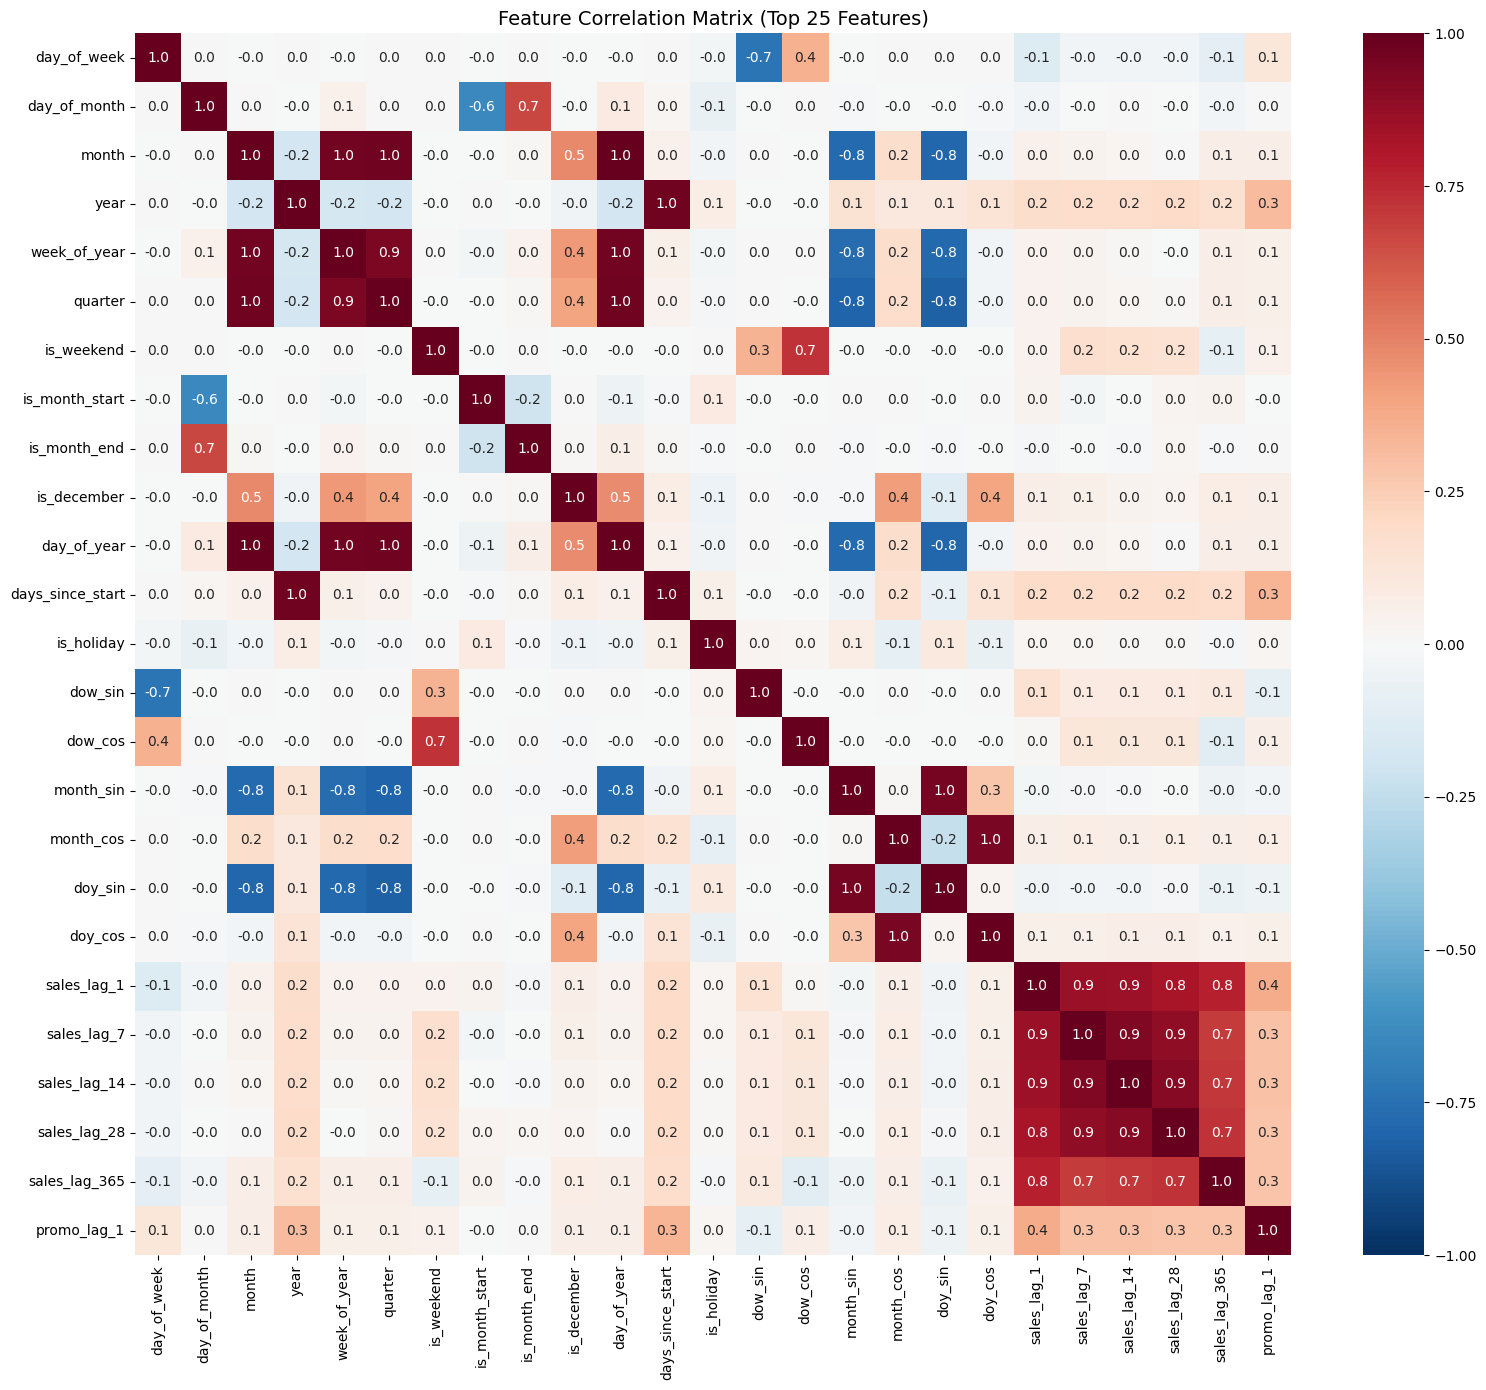

In [ ]:
# ============================================
# TOP 1% ADDITION: Check for multicollinearity
# Run this AFTER converting to Pandas
#
# WHY THIS MATTERS:
# If two features are 95% correlated, they carry
# the same information. One of them is redundant.
# Including both wastes model capacity and can cause
# instability in linear models.
#
# BUSINESS ANALOGY:
# If you know "monthly revenue" and "monthly profit",
# you don't also need "monthly revenue minus costs"
# because that's literally the same as profit.
# ============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
numeric_features = train_pandas[feature_columns].select_dtypes(include=[np.number])
corr_matrix = numeric_features.corr()

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.95:
            high_corr_pairs.append({
                'feature_1': corr_matrix.columns[i],
                'feature_2': corr_matrix.columns[j],
                'correlation': round(corr_matrix.iloc[i, j], 3)
            })

if high_corr_pairs:
    print("⚠️  Highly correlated feature pairs (>0.95):")
    print("   Consider removing one from each pair:\n")
    for pair in high_corr_pairs:
        print(f"   {pair['feature_1']} ↔ {pair['feature_2']}: {pair['correlation']}")
else:
    print("✅ No highly correlated feature pairs found (>0.95)")

# Plot heatmap of top features
plt.figure(figsize=(16, 14))
top_features = feature_columns[:25]  # First 25 for readability
sns.heatmap(
    numeric_features[top_features].corr(),
    annot=True, fmt='.1f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1
)
plt.title('Feature Correlation Matrix (Top 25 Features)', fontsize=14)
plt.tight_layout()
plt.savefig('feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

###Improvement 3: Feature Importance Sanity Check

In [ ]:
# ============================================
# TOP 1% ADDITION: Quick feature importance check
# Train a fast model JUST to validate features make sense
# This happens BEFORE the full model training (Week 3)
#
# WHY:
# If your most important feature is "day_of_month" and
# not "sales_lag_1", something might be wrong.
# This catches issues early.
# ============================================

from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Quick train on a sample
sample = train_pandas.sample(n=min(50000, len(train_pandas)), random_state=42)
X_sample = sample[feature_columns].fillna(0)
y_sample = sample[target]

quick_model = RandomForestRegressor(n_estimators=100, max_depth=10,
                                      n_jobs=-1, random_state=42)
quick_model.fit(X_sample, y_sample)

# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': quick_model.feature_importances_
}).sort_values('importance', ascending=False)

print("TOP 15 MOST IMPORTANT FEATURES (Quick Validation):")
print("=" * 55)
for i, row in importance_df.head(15).iterrows():
    bar = '█' * int(row['importance'] * 200)
    print(f"  {row['feature']:<30} {row['importance']:.4f} {bar}")

print("\n" + "=" * 55)
print("SANITY CHECK:")
if importance_df.iloc[0]['feature'].startswith('sales_lag'):
    print(" ⚠️ Top feature is a lag feature — makes sense!")
    print("   (Expected a lag feature. Investigate if this makes sense.)")
else:
    print(f"✅ Top feature is {importance_df.iloc[0]['feature']}")
    print("    Recent sales are the strongest predictor")

TOP 15 MOST IMPORTANT FEATURES (Quick Validation):
  rolling_mean_7                 0.4987 ███████████████████████████████████████████████████████████████████████████████████████████████████
  sales_lag_7                    0.3225 ████████████████████████████████████████████████████████████████
  category_avg_all_stores        0.1060 █████████████████████
  sales_lag_14                   0.0219 ████
  sales_lag_1                    0.0105 ██
  expanding_std                  0.0093 █
  sales_lag_28                   0.0050 █
  cluster                        0.0028 
  rolling_std_7                  0.0022 
  rolling_max_7                  0.0019 
  rolling_max_14                 0.0014 
  expanding_mean                 0.0013 
  rolling_std_14                 0.0010 
  rolling_mean_30                0.0010 
  day_of_month                   0.0010 

SANITY CHECK:
✅ Top feature is rolling_mean_7
    Recent sales are the strongest predictor
